# EDA - Base de películas IMDB (TP Grupal)

Análisis exploratorio de `movie.sqlite`: características generales del dataset,
tipos de variables, estadística descriptiva y relaciones. Sirve de base para las
diapositivas del grupo.

In [54]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## 1. Carga desde SQLite e inspección

La base tiene 3 tablas relacionadas por `Movie_id`.

In [55]:
con = sqlite3.connect("movie.sqlite")
tablas = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", con)
print(tablas["name"].tolist())

imdb = pd.read_sql("SELECT * FROM IMDB", con)
earning = pd.read_sql("SELECT * FROM earning", con)
genre = pd.read_sql("SELECT * FROM genre", con)
con.close()

print("IMDB:", imdb.shape, "| earning:", earning.shape, "| genre:", genre.shape)

['IMDB', 'earning', 'genre']
IMDB: (117, 52) | earning: (117, 3) | genre: (351, 2)


In [56]:
imdb.iloc[:, :8].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Movie_id    117 non-null    object 
 1   Title       117 non-null    object 
 2   Rating      117 non-null    float64
 3   TotalVotes  117 non-null    int64  
 4   MetaCritic  117 non-null    object 
 5   Budget      117 non-null    object 
 6   Runtime     117 non-null    object 
 7   CVotes10    117 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 7.4+ KB


### Diccionario de datos

Qué representa cada campo de las 3 tablas. La mayoría de las columnas de `IMDB` son
el voto desagregado por demografía, con dos prefijos: **`CVotes*`** = *cantidad* de
votos de ese grupo y **`Votes*`** = *rating promedio* que dio ese grupo.

In [57]:
# Diccionario de datos: qué representa cada campo
# Convención: CVotes* = CANTIDAD de votos de un grupo | Votes* = RATING PROMEDIO de ese grupo
desc = {
    # --- IMDB: contenido ---
    "Movie_id": "Identificador único de la película (clave para unir las 3 tablas)",
    "Title": "Título de la película (incluye el año)",
    "Rating": "Calificación promedio en IMDB (escala 0-10)",
    "TotalVotes": "Cantidad total de votos recibidos en IMDB",
    "MetaCritic": "Puntaje de Metacritic (escala 0-100)",
    "Budget": "Presupuesto de producción (USD)",
    "Runtime": "Duración de la película (minutos)",
    # --- IMDB: cantidad de votos por puntaje otorgado ---
    **{f"CVotes{n:02d}": f"Cantidad de votos con puntaje {n}" for n in range(10, 0, -1)},
    # --- IMDB: cantidad de votos por género ---
    "CVotesMale": "Cantidad de votos de usuarios varones",
    "CVotesFemale": "Cantidad de votos de usuarias mujeres",
    # --- IMDB: cantidad de votos por edad (y género) ---
    "CVotesU18": "Cantidad de votos de menores de 18 años",
    "CVotesU18M": "Cantidad de votos de varones menores de 18 años",
    "CVotesU18F": "Cantidad de votos de mujeres menores de 18 años",
    "CVotes1829": "Cantidad de votos de usuarios de 18 a 29 años",
    "CVotes1829M": "Cantidad de votos de varones de 18 a 29 años",
    "CVotes1829F": "Cantidad de votos de mujeres de 18 a 29 años",
    "CVotes3044": "Cantidad de votos de usuarios de 30 a 44 años",
    "CVotes3044M": "Cantidad de votos de varones de 30 a 44 años",
    "CVotes3044F": "Cantidad de votos de mujeres de 30 a 44 años",
    "CVotes45A": "Cantidad de votos de usuarios de 45 años o más",
    "CVotes45AM": "Cantidad de votos de varones de 45 años o más",
    "CVotes45AF": "Cantidad de votos de mujeres de 45 años o más",
    # --- IMDB: cantidad de votos por origen / segmento ---
    "CVotes1000": "Cantidad de votos de los Top 1000 votantes de IMDB",
    "CVotesUS": "Cantidad de votos de usuarios de Estados Unidos",
    "CVotesnUS": "Cantidad de votos de usuarios fuera de Estados Unidos",
    # --- IMDB: rating promedio por grupo ---
    "VotesM": "Rating promedio otorgado por varones",
    "VotesF": "Rating promedio otorgado por mujeres",
    "VotesU18": "Rating promedio otorgado por menores de 18 años",
    "VotesU18M": "Rating promedio otorgado por varones menores de 18 años",
    "VotesU18F": "Rating promedio otorgado por mujeres menores de 18 años",
    "Votes1829": "Rating promedio otorgado por usuarios de 18 a 29 años",
    "Votes1829M": "Rating promedio otorgado por varones de 18 a 29 años",
    "Votes1829F": "Rating promedio otorgado por mujeres de 18 a 29 años",
    "Votes3044": "Rating promedio otorgado por usuarios de 30 a 44 años",
    "Votes3044M": "Rating promedio otorgado por varones de 30 a 44 años",
    "Votes3044F": "Rating promedio otorgado por mujeres de 30 a 44 años",
    "Votes45A": "Rating promedio otorgado por usuarios de 45 años o más",
    "Votes45AM": "Rating promedio otorgado por varones de 45 años o más",
    "Votes45AF": "Rating promedio otorgado por mujeres de 45 años o más",
    "VotesIMDB": "Rating promedio general reportado por IMDB",
    "Votes1000": "Rating promedio otorgado por los Top 1000 votantes",
    "VotesUS": "Rating promedio otorgado por usuarios de Estados Unidos",
    "VotesnUS": "Rating promedio otorgado por usuarios fuera de Estados Unidos",
    # --- earning ---
    "Domestic": "Recaudación en EE.UU. y Canadá (USD)",
    "Worldwide": "Recaudación mundial total (USD)",
    # --- genre ---
    "genre": "Género de la película (una fila por género; relación 1-a-muchos)",
}

filas = []
for tabla, cols in [("IMDB", imdb.columns), ("earning", earning.columns), ("genre", genre.columns)]:
    for c in cols:
        filas.append({"tabla": tabla, "campo": c, "descripción": desc.get(c, "")})

diccionario = pd.DataFrame(filas)
pd.set_option("display.max_rows", None, "display.max_colwidth", None)
diccionario

,tabla,campo,descripción
0,IMDB,Movie_id,Identificador único de la película (clave para unir las 3 tablas)
1,IMDB,Title,Título de la película (incluye el año)
2,IMDB,Rating,Calificación promedio en IMDB (escala 0-10)
3,IMDB,TotalVotes,Cantidad total de votos recibidos en IMDB
4,IMDB,MetaCritic,Puntaje de Metacritic (escala 0-100)
5,IMDB,Budget,Presupuesto de producción (USD)
6,IMDB,Runtime,Duración de la película (minutos)
7,IMDB,CVotes10,Cantidad de votos con puntaje 10
8,IMDB,CVotes09,Cantidad de votos con puntaje 9
9,IMDB,CVotes08,Cantidad de votos con puntaje 8


## 2. Tipos de variables y limpieza

Varias columnas numéricas vienen guardadas como texto (con vacíos y unidades),
así que hay que convertirlas.

In [ ]:
# Runtime viene como '134 min'; MetaCritic y Budget como texto con vacíos
imdb["Runtime"] = pd.to_numeric(
    imdb["Runtime"].astype(str).str.replace(" min", "", regex=False), errors="coerce")
imdb["MetaCritic"] = pd.to_numeric(imdb["MetaCritic"], errors="coerce")
imdb["Budget"] = pd.to_numeric(imdb["Budget"], errors="coerce")

# Unimos películas con su recaudación
df = imdb.merge(earning, on="Movie_id", how="left")
print("Dataset unido:", df.shape)

# Nulos que aparecen tras la conversión
faltantes = df[["MetaCritic", "Budget", "Runtime", "Worldwide"]].isna().sum()
faltantes

Dataset unido: (117, 54)


,0
MetaCritic,7
Budget,3
Runtime,21
Worldwide,0


In [53]:
# Género tiene una relación 1-a-muchos y algunas filas vacías
print("Filas en genre:", len(genre), "| géneros únicos:", genre["genre"].nunique())
print("Filas con género vacío:", (genre["genre"] == "").sum())

Filas en genre: 351 | géneros únicos: 21
Filas con género vacío: 41


## 3. Estadística descriptiva

In [50]:
num_foco = ["Rating", "Runtime", "MetaCritic", "Budget", "Worldwide", "TotalVotes"]
df[num_foco].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
Rating,117.0,7.9,0.2,7.5,7.7,7.8,8.0,8.800000e+00
Runtime,96.0,126.6,19.6,91.0,112.8,125.5,138.2,1.800000e+02
MetaCritic,110.0,77.8,8.9,62.0,72.0,77.5,82.8,1.000000e+02
Budget,114.0,74596491.2,75078810.4,1000000.0,15000000.0,40000000.0,148750000.0,2.600000e+08
Worldwide,117.0,340378011.8,371945532.5,22321.0,68263166.0,201634991.0,494878759.0,2.068224e+09
TotalVotes,117.0,375579.1,262705.6,26016.0,222343.0,337571.0,512526.0,1.609713e+06


In [51]:
# Forma de la distribución del rating
pd.Series({
    "media": df["Rating"].mean(),
    "mediana": df["Rating"].median(),
    "moda": df["Rating"].mode().iloc[0],
    "desv_std": df["Rating"].std(),
    "skew": df["Rating"].skew(),
    "curtosis": df["Rating"].kurt(),
}).round(2)

,0
media,7.87
mediana,7.80
moda,7.80
desv_std,0.24
skew,1.00
curtosis,1.59


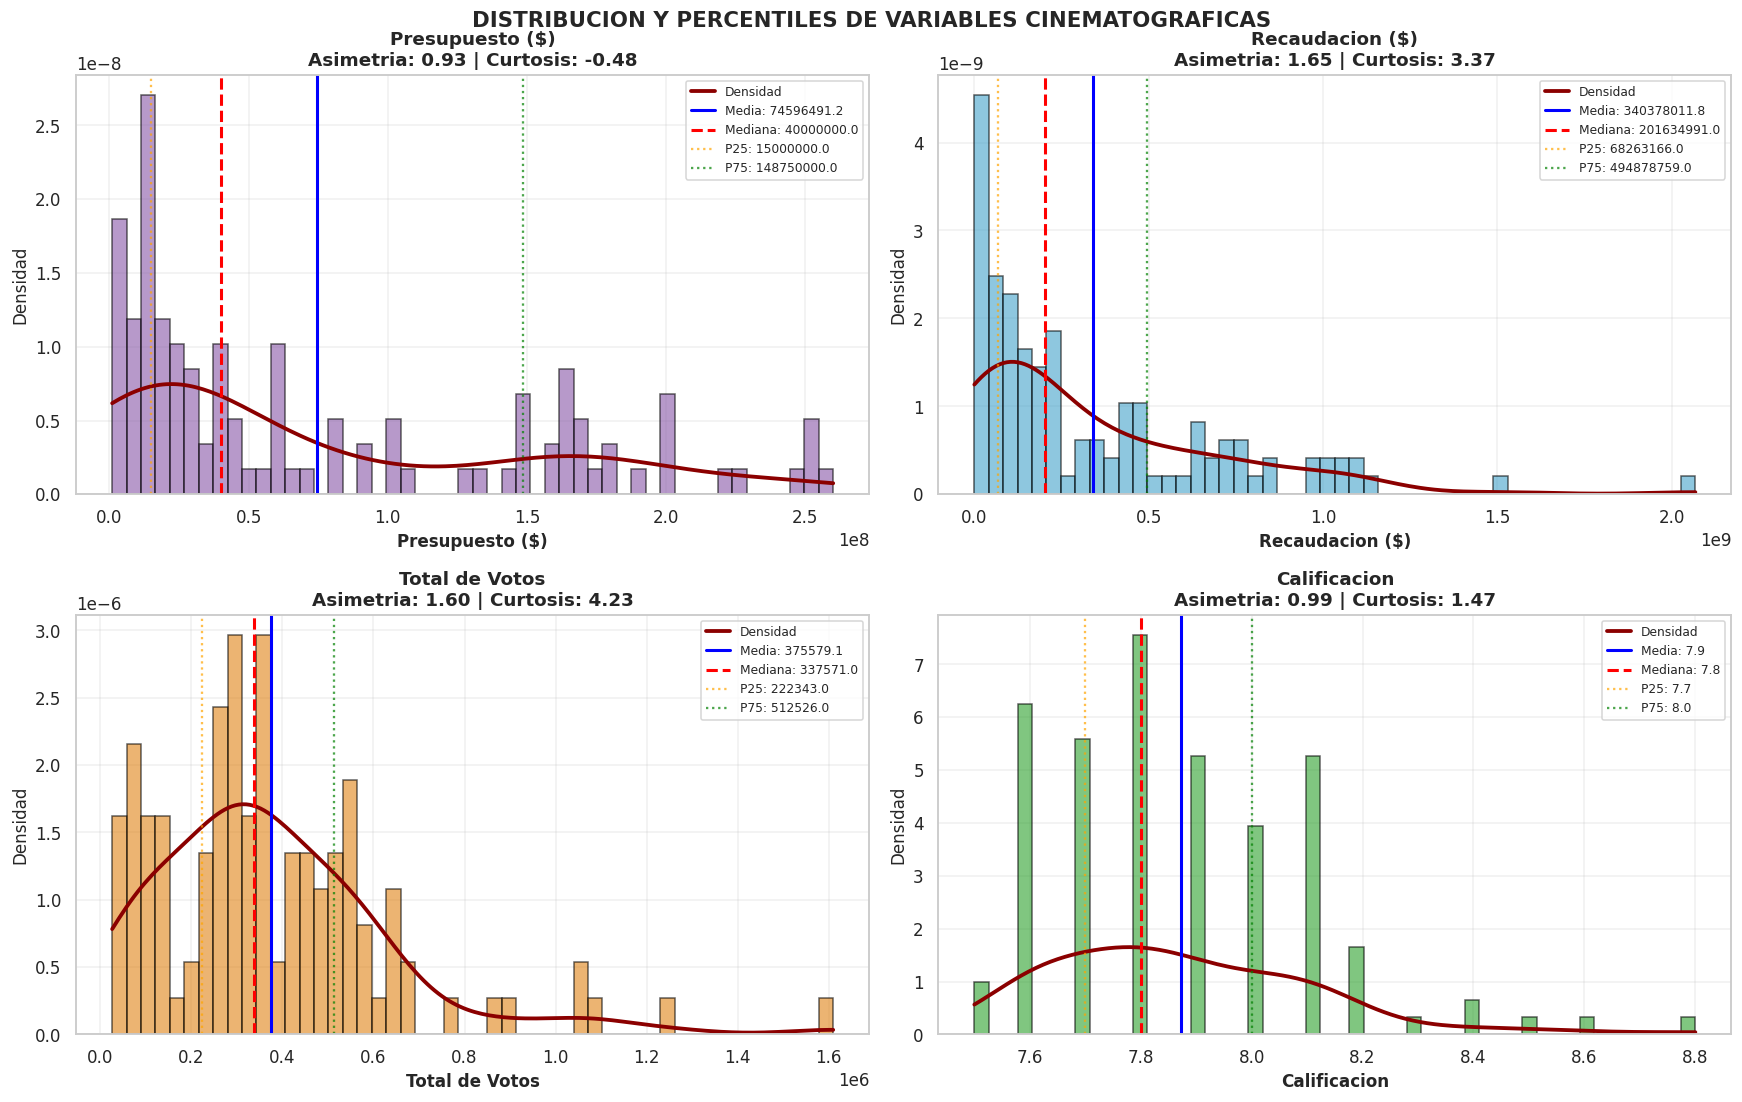


TABLA DE PERCENTILES (25%, 50%, 75%)
           Budget    Worldwide  TotalVotes  Rating
0.25   15000000.0   68263166.0    222343.0     7.7
0.50   40000000.0  201634991.0    337571.0     7.8
0.75  148750000.0  494878759.0    512526.0     8.0


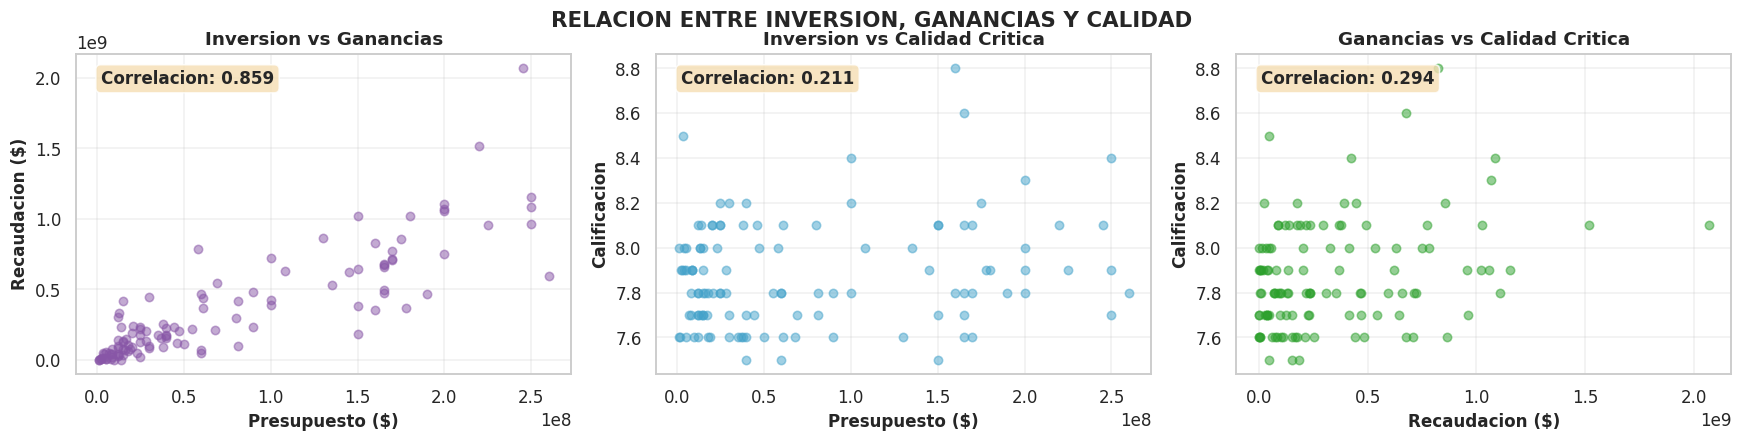


ESTADISTICOS DE FORMA DE LA DISTRIBUCION
Variable             Asimetria       Curtosis        Interpretacion                          
Budget               0.928           -0.476          Cola larga derecha (concentracion extrema)
Worldwide            1.648           3.365           Cola larga derecha (concentracion extrema)
TotalVotes           1.599           4.229           Cola larga derecha (concentracion extrema)
Rating               0.991           1.473           Cola larga derecha (concentracion extrema)


In [71]:
from scipy.stats import skew, kurtosis, pearsonr
import numpy as np
import seaborn as sns

# ==========================================
# 1. GRAFICAS DE DISTRIBUCION (4 variables)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

variables = ["Budget", "Worldwide", "TotalVotes", "Rating"]
colors = ["#8856a7", "#43a2ca", "#e08214", "#2ca02c"]
labels = ["Presupuesto ($)", "Recaudacion ($)", "Total de Votos", "Calificacion"]

for idx, (var, color, label) in enumerate(zip(variables, colors, labels)):
    # Histograma
    axes[idx].hist(df[var], bins=50, color=color, alpha=0.6, edgecolor="black", density=True)

    # Curva de densidad (KDE)
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(df[var].dropna())
    x_range = np.linspace(df[var].min(), df[var].max(), 200)
    axes[idx].plot(x_range, kde(x_range), color="darkred", linewidth=2.5, label="Densidad")

    # Lineas de media y mediana
    media = df[var].mean()
    mediana = df[var].median()
    axes[idx].axvline(media, color="blue", linestyle="-", linewidth=2, label=f"Media: {media:.1f}")
    axes[idx].axvline(mediana, color="red", linestyle="--", linewidth=2, label=f"Mediana: {mediana:.1f}")

    # Percentiles 25, 50, 75
    p25, p50, p75 = df[var].quantile([0.25, 0.50, 0.75])
    axes[idx].axvline(p25, color="orange", linestyle=":", linewidth=1.5, alpha=0.7, label=f"P25: {p25:.1f}")
    axes[idx].axvline(p75, color="green", linestyle=":", linewidth=1.5, alpha=0.7, label=f"P75: {p75:.1f}")

    # Estadisticos de forma
    asimetria = skew(df[var].dropna())
    curt = kurtosis(df[var].dropna())

    axes[idx].set_xlabel(label, fontsize=11, fontweight="bold")
    axes[idx].set_ylabel("Densidad", fontsize=11)
    axes[idx].set_title(f"{label}\nAsimetria: {asimetria:.2f} | Curtosis: {curt:.2f}",
                        fontsize=12, fontweight="bold")
    axes[idx].legend(fontsize=8, loc="upper right")
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle("DISTRIBUCION Y PERCENTILES DE VARIABLES CINEMATOGRAFICAS",
             fontsize=14, fontweight="bold", y=1.00)
plt.show()

# ==========================================
# 2. TABLA DE PERCENTILES
# ==========================================
print("\n" + "="*90)
print("TABLA DE PERCENTILES (25%, 50%, 75%)")
print("="*90)
percentiles = [0.25, 0.50, 0.75]
print(df[["Budget", "Worldwide", "TotalVotes", "Rating"]].quantile(percentiles).to_string())
print("="*90)

# ==========================================
# 3. MATRIZ DE CORRELACION
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Budget vs Worldwide
ax1 = axes[0]
ax1.scatter(df["Budget"], df["Worldwide"], alpha=0.5, color="#8856a7", s=30)
ax1.set_xlabel("Presupuesto ($)", fontsize=11, fontweight="bold")
ax1.set_ylabel("Recaudacion ($)", fontsize=11, fontweight="bold")
ax1.set_title("Inversion vs Ganancias", fontsize=12, fontweight="bold")
corr_bw = df["Budget"].corr(df["Worldwide"])
ax1.text(0.05, 0.95, f"Correlacion: {corr_bw:.3f}",
         transform=ax1.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontweight="bold")
ax1.grid(alpha=0.3)

# Budget vs Rating
ax2 = axes[1]
ax2.scatter(df["Budget"], df["Rating"], alpha=0.5, color="#43a2ca", s=30)
ax2.set_xlabel("Presupuesto ($)", fontsize=11, fontweight="bold")
ax2.set_ylabel("Calificacion", fontsize=11, fontweight="bold")
ax2.set_title("Inversion vs Calidad Critica", fontsize=12, fontweight="bold")
corr_br = df["Budget"].corr(df["Rating"])
ax2.text(0.05, 0.95, f"Correlacion: {corr_br:.3f}",
         transform=ax2.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontweight="bold")
ax2.grid(alpha=0.3)

# Worldwide vs Rating
ax3 = axes[2]
ax3.scatter(df["Worldwide"], df["Rating"], alpha=0.5, color="#2ca02c", s=30)
ax3.set_xlabel("Recaudacion ($)", fontsize=11, fontweight="bold")
ax3.set_ylabel("Calificacion", fontsize=11, fontweight="bold")
ax3.set_title("Ganancias vs Calidad Critica", fontsize=12, fontweight="bold")
corr_wr = df["Worldwide"].corr(df["Rating"])
ax3.text(0.05, 0.95, f"Correlacion: {corr_wr:.3f}",
         transform=ax3.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontweight="bold")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle("RELACION ENTRE INVERSION, GANANCIAS Y CALIDAD",
             fontsize=14, fontweight="bold", y=1.00)
plt.show()

# ==========================================
# 4. TABLA RESUMEN FINAL
# ==========================================
print("\n" + "="*90)
print("ESTADISTICOS DE FORMA DE LA DISTRIBUCION")
print("="*90)
print(f"{'Variable':<20} {'Asimetria':<15} {'Curtosis':<15} {'Interpretacion':<40}")
print("="*90)

for var in variables:
    asim = skew(df[var].dropna())
    curt = kurtosis(df[var].dropna())

    if asim > 0.5:
        interp = "Cola larga derecha (concentracion extrema)"
    elif asim < -0.5:
        interp = "Cola larga izquierda"
    else:
        interp = "Simetrica (distribucion uniforme)"

    print(f"{var:<20} {asim:<15.3f} {curt:<15.3f} {interp:<40}")
print("="*90)



   *En la industria cinematográfica, el dinero determina GANANCIAS pero NO CALIDAD.
   Un blockbuster de 200M y una película independiente de 5M pueden recibir
   la misma calificación crítica (~7.8), pero la recaudación será completamente diferente.*

## 4. Variables categóricas: géneros

In [ ]:
top_generos = (genre[genre["genre"] != ""]["genre"]
               .value_counts().head(10))
top_generos

,count
genre,
Drama,77
Adventure,43
Action,33
Comedy,31
Biography,21
Sci-Fi,18
Thriller,14
Romance,13
Animation,13


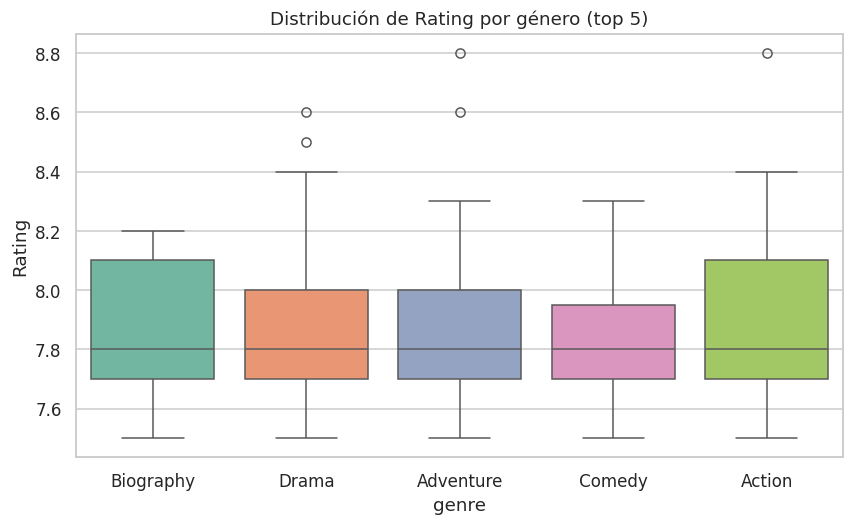

In [59]:
# Traer el género a nivel película (unir con genre, sacando vacíos)
genre_valid = genre[genre["genre"] != ""]
top5_generos = genre_valid["genre"].value_counts().head(5).index

df_genre = df.merge(genre_valid, on="Movie_id", how="inner")
df_genre_top5 = df_genre[df_genre["genre"].isin(top5_generos)]

plt.figure(figsize=(9,5))
sns.boxplot(data=df_genre_top5, x="genre", y="Rating", hue="genre", palette="Set2", legend=False)
plt.title("Distribución de Rating por género (top 5)")
plt.show()

*El género tiene POCO poder explicativo sobre la calidad*

## 5. Relaciones entre variables

Correlación entre presupuesto, recaudación, rating, duración y votos.

In [ ]:
cols_corr = ["Budget", "Worldwide", "Domestic", "Rating", "Runtime", "TotalVotes", "MetaCritic"]
corr = df[cols_corr].corr()
corr.round(2)

,Budget,Worldwide,Domestic,Rating,Runtime,TotalVotes,MetaCritic
Budget,1.00,0.86,0.78,0.21,0.40,0.51,-0.21
Worldwide,0.86,1.00,0.96,0.29,0.32,0.58,-0.12
Domestic,0.78,0.96,1.00,0.26,0.27,0.54,-0.12
Rating,0.21,0.29,0.26,1.00,0.27,0.63,0.15
Runtime,0.40,0.32,0.27,0.27,1.00,0.42,-0.23
TotalVotes,0.51,0.58,0.54,0.63,0.42,1.00,-0.05
MetaCritic,-0.21,-0.12,-0.12,0.15,-0.23,-0.05,1.00


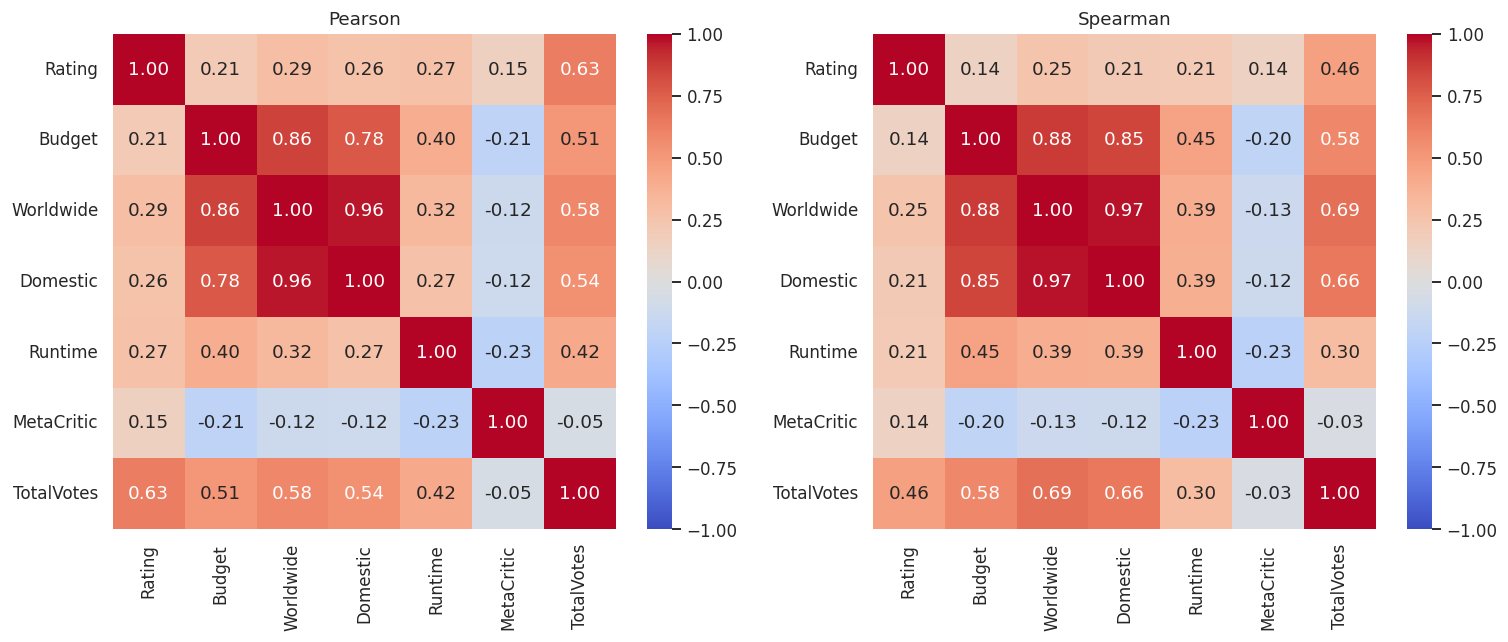

In [39]:
# Comparar Pearson vs Spearman
corr_spearman = df[cols_corr].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson")
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Spearman")
plt.tight_layout()
plt.show()

*El dinero genera dinero, pero NO calidad. La calidad depende de aspectos creativos, no del presupuesto.*

- *Si inviertes MÁS dinero GANAS más dinero*

- *Si inviertes MÁS dinero NO necesariamente recibes mejor calificación*

- *Si GANAS más dinero NO necesariamente la película es mejor*

- *Si la película es MÁS POPULAR recibe MEJOR calificación*

- *Las películas MÁS LARGAS NO son necesariamente mejor calificadas*

- *Presupuesto alto Críticos profesionales MENOS entusiastas*



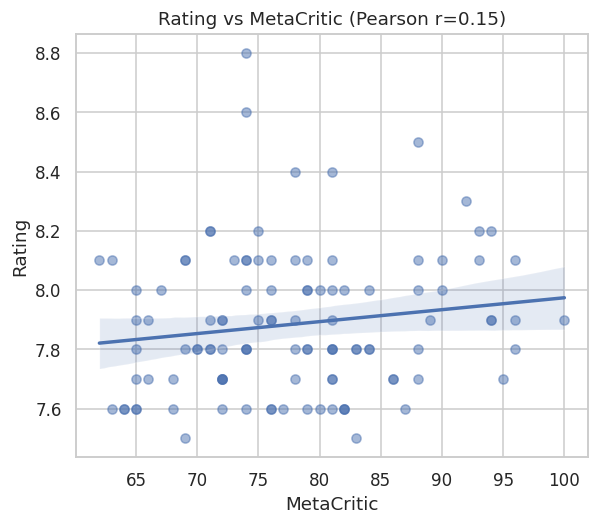

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))
sns.regplot(data=df, x="MetaCritic", y="Rating", scatter_kws={"alpha":0.5}, ax=ax)
ax.set_title(f"Rating vs MetaCritic (Pearson r={df['Rating'].corr(df['MetaCritic']):.2f})")
plt.show()

*Los críticos profesionales y el público NO coinciden en sus opiniones*


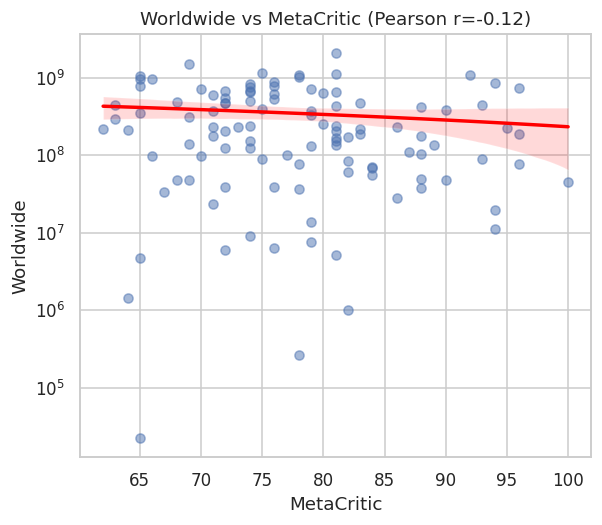

In [60]:
fig, ax = plt.subplots(figsize=(6,5))
sns.regplot(data=df, x="MetaCritic", y="Worldwide", scatter_kws={"alpha":0.5}, ax=ax, line_kws={"color":"red"})
ax.set_yscale("log")
ax.set_title(f"Worldwide vs MetaCritic (Pearson r={df['Worldwide'].corr(df['MetaCritic']):.2f})")
plt.show()

*Cuando los críticos califican MEJOR una película, TIENDE a ganar MENOS dinero*

## 6. Visualizaciones

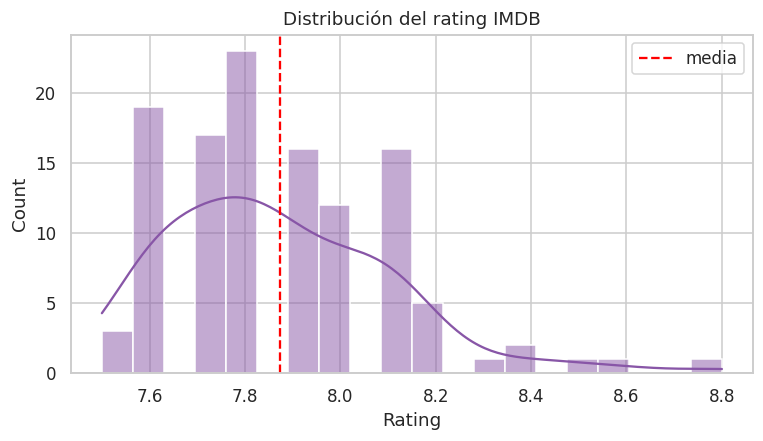

In [ ]:
# Distribución del rating
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["Rating"], bins=20, kde=True, color="#8856a7", ax=ax)
ax.axvline(df["Rating"].mean(), color="red", ls="--", label="media")
ax.set_title("Distribución del rating IMDB")
ax.legend()
plt.show()

*Casi todas las películas se concentran entre 7.6 y 8.0 de rating; muy pocas superan 8.4.
La distribución tiene asimetría positiva y la media (línea roja) ronda 7.9. Es un dataset
de films ya "prestigiosos", con poco rango de rating.*

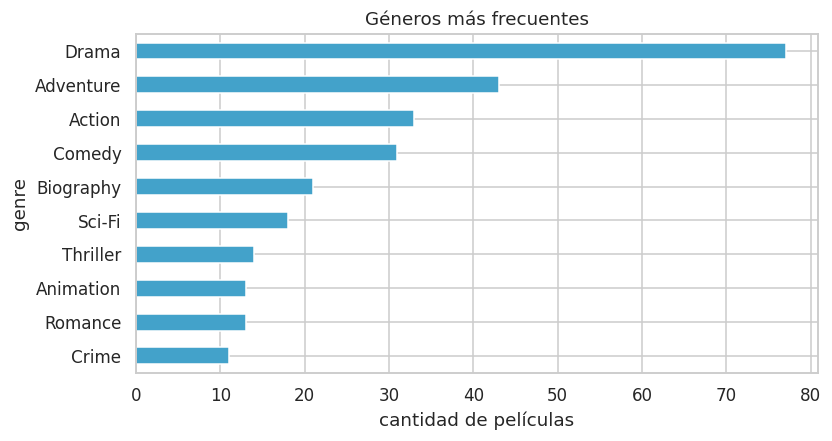

In [ ]:
# Géneros más frecuentes
fig, ax = plt.subplots(figsize=(8, 4))
top_generos.sort_values().plot.barh(color="#43a2ca", ax=ax)
ax.set_title("Géneros más frecuentes")
ax.set_xlabel("cantidad de películas")
plt.show()

*Drama es por lejos el género más frecuente (77 películas), seguido de Adventure y Action.
Como cada película puede tener varios géneros (relación 1-a-muchos), la suma de las barras
supera la cantidad total de films.*

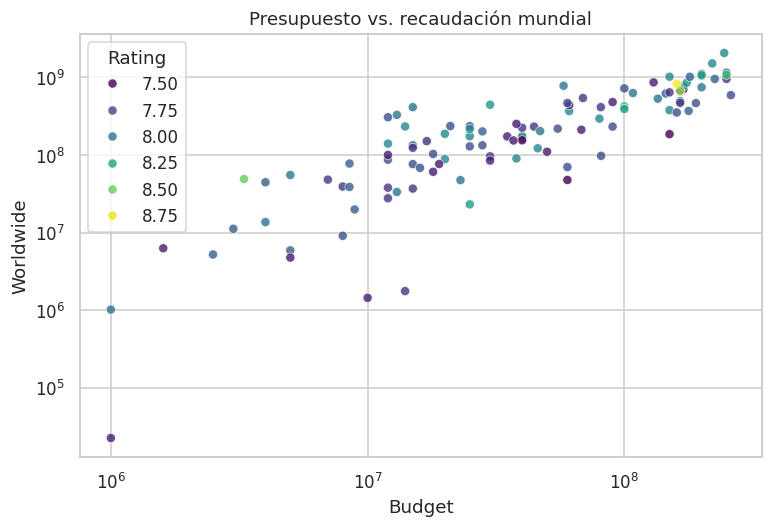

In [ ]:
# Presupuesto vs recaudación mundial (escala log)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="Budget", y="Worldwide", hue="Rating",
                palette="viridis", alpha=0.8, ax=ax)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title("Presupuesto vs. recaudación mundial")
plt.show()

*En escala logarítmica se ve una relación positiva clara: a mayor presupuesto, mayor
recaudación mundial. El color (rating) no muestra un patrón marcado con la taquilla:
películas caras y taquilleras no son necesariamente las mejor puntuadas.*

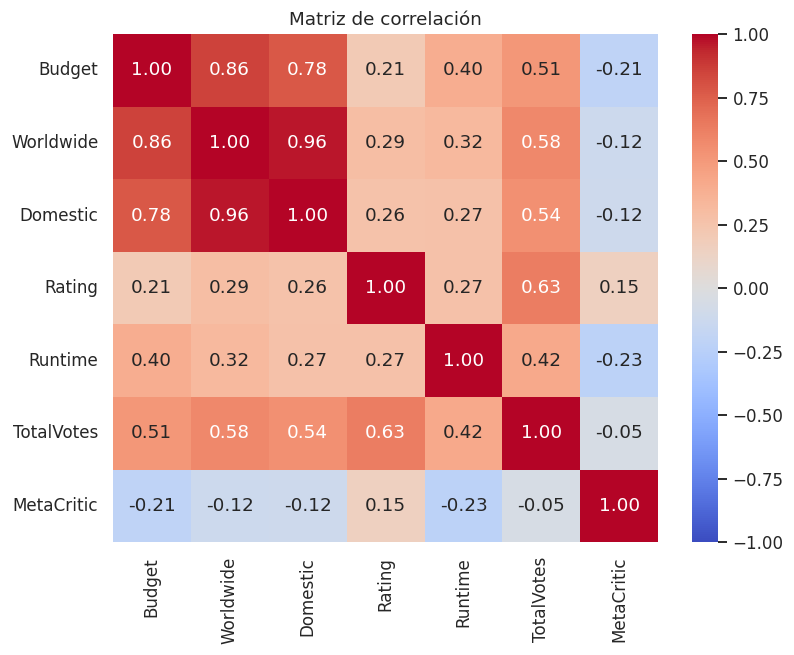

In [ ]:
# Heatmap de correlación
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlación")
plt.show()

*Budget y Worldwide están muy correlacionados (0.86), y Worldwide con Domestic casi de
forma perfecta (0.96). El rating correlaciona poco con la plata y algo más con la cantidad
de votos (0.63). MetaCritic aporta correlaciones bajas o negativas con lo comercial.*

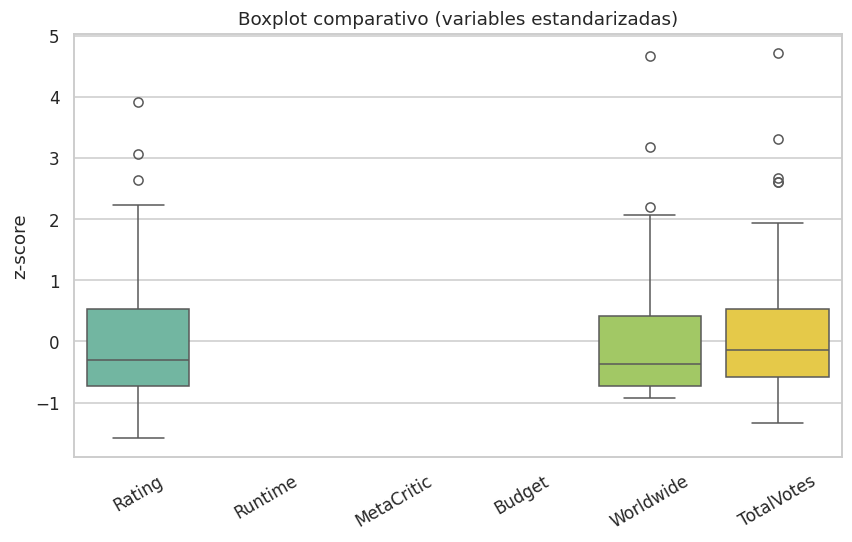

In [38]:
from scipy.stats import zscore

fig, ax = plt.subplots(figsize=(9,5))
df_z = df[num_foco].apply(zscore)
sns.boxplot(data=df_z, ax=ax, palette="Set2")
ax.set_title("Boxplot comparativo (variables estandarizadas)")
ax.set_ylabel("z-score")
plt.xticks(rotation=30)
plt.show()

*Este gráfico muestra que hay dos tipos de distribuciones. Rating, Runtime, MetaCritic y Budget tienen distribuciones normales, lo que significa que la mayoría de películas son similares. Sin embargo, Worldwide y TotalVotes tienen distribuciones sesgadas con muchos outliers, lo que indica que algunos blockbusters ganan MUCHÍSIMO más dinero y reciben muchos más votos que el promedio.*

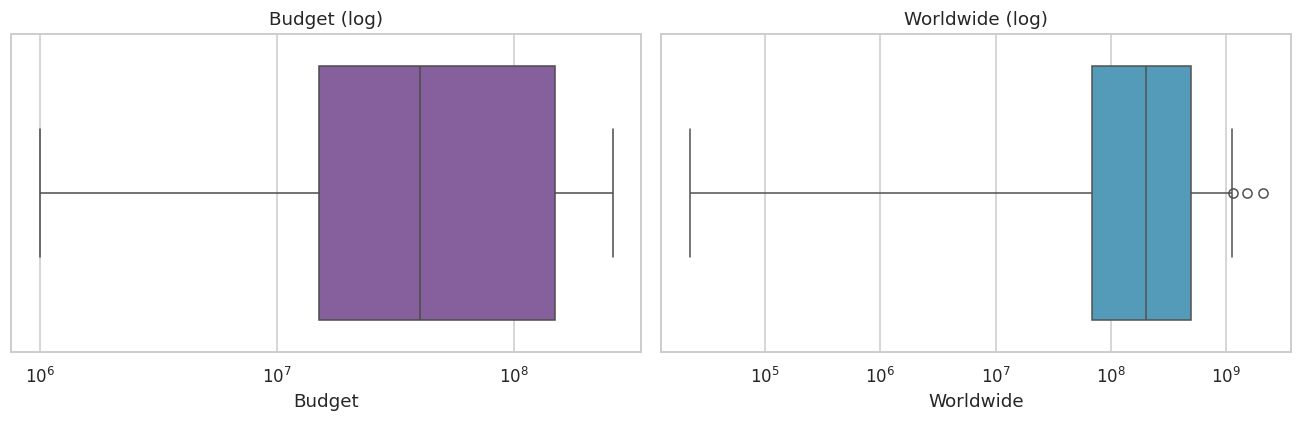

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df["Budget"], ax=axes[0], color="#8856a7")
axes[0].set_xscale("log")
axes[0].set_title("Budget (log)")
sns.boxplot(x=df["Worldwide"], ax=axes[1], color="#43a2ca")
axes[1].set_xscale("log")
axes[1].set_title("Worldwide (log)")
plt.tight_layout()
plt.show()

*Estos gráficos usan escala logarítmica, que es una forma especial de graficar números muy grandes juntos. En el Budget, la mayoría de películas cuestan entre 10M y 100M, y en escala logarítmica esto se ve como una distribución casi normal. Sin embargo, en Worldwide (ganancias), incluso en escala logarítmica, hay 2-3 películas que ganan MUCHÍSIMO más que el resto. Esto prueba que los outliers no son un error visual, sino un patrón REAL de la industria: algunos blockbusters dominan completamente las ganancias.*

## 7. Resumen para las diapositivas

In [ ]:
resumen = {
    "peliculas": len(df),
    "columnas_totales": imdb.shape[1] + 2,  # IMDB + Domestic/Worldwide
    "num_numericas": df.select_dtypes("number").shape[1],
    "generos_unicos": genre[genre["genre"] != ""]["genre"].nunique(),
    "nulos_MetaCritic": int(df["MetaCritic"].isna().sum()),
    "nulos_Budget": int(df["Budget"].isna().sum()),
    "nulos_Runtime": int(df["Runtime"].isna().sum()),
    "generos_vacios": int((genre["genre"] == "").sum()),
    "top_genero": top_generos.index[0],
    "mas_votada": df.loc[df["TotalVotes"].idxmax(), "Title"],
    "mayor_recaudacion": df.loc[df["Worldwide"].idxmax(), "Title"],
    "rating_promedio": round(df["Rating"].mean(), 1),
}
for k, v in resumen.items():
    print(f"{k}: {v}")

peliculas: 117
columnas_totales: 54
num_numericas: 7
generos_unicos: 20
nulos_MetaCritic: 7
nulos_Budget: 3
nulos_Runtime: 21
generos_vacios: 41
top_genero: Drama
mas_votada: Inception (2010)
mayor_recaudacion: Star Wars: The Force Awakens (2015)
rating_promedio: 7.9


In [ ]:
# Momentos estadísticos para todas las variables numéricas de interés
momentos = pd.DataFrame({
    "media": df[num_foco].mean(),
    "mediana": df[num_foco].median(),
    "desv_std": df[num_foco].std(),
    "skew": df[num_foco].skew(),
    "kurtosis": df[num_foco].kurt(),
}).round(2)
momentos



,media,mediana,desv_std,skew,kurtosis
Rating,7.870000e+00,7.8,2.400000e-01,1.00,1.59
Runtime,1.265600e+02,125.5,1.965000e+01,0.45,-0.25
MetaCritic,7.781000e+01,77.5,8.860000e+00,0.38,-0.46
Budget,7.459649e+07,40000000.0,7.507881e+07,0.94,-0.44
Worldwide,3.403780e+08,201634991.0,3.719455e+08,1.67,3.57
TotalVotes,3.755791e+05,337571.0,2.627056e+05,1.62,4.47
